<a href="https://colab.research.google.com/github/OuhmadMohamed/DI_Bootcamp/blob/main/Week8/Day1/Exercises_XP_Student_w8_d1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Text Preprocessing, NER, POS, and Word2Vec

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells marked TODO expect your code or analysis.

## What you will learn
- Clean and normalize raw reviews with tokenization, stopword removal, and lemmatization.
- Extract linguistic features with named entity recognition (NER) and part-of-speech (POS) tagging.
- Train a simple Word2Vec model and interpret its vector dimensions.
- Visualize word embeddings to reason about semantic neighborhoods.

## What you will create
- A `preprocess_text` function that lowercases, strips punctuation, removes stopwords, and lemmatizes.
- `perform_ner` and `perform_pos_tagging` helpers to analyze raw vs cleaned text.
- A Word2Vec model plus a helper to plot embeddings for inspection.

> Learning point
> Run the setup cells once, then progress through each exercise sequentially. Print intermediate results to verify every helper works before moving on.

## Setup · install libraries
Run once to install spaCy, nltk, gensim, and plotting utilities.

In [ ]:
%pip install --quiet spacy nltk gensim matplotlib seaborn --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 55.7 MB/s eta 0:00:00


In [ ]:
import nltk
from spacy.cli import download as spacy_download
import spacy

resources = [
    "punkt",
    "punkt_tab",
    "wordnet",
    "omw-1.4",
    "stopwords",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
    "tagsets",
]
for res in resources:
    nltk.download(res, quiet=True)

spacy_download("en_core_web_sm")

nlp = spacy.load("en_core_web_sm")
print("spaCy pipeline:", nlp.pipe_names)


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
spaCy pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## Exercise 1 · Explore text preprocessing, NER, and POS tags

Here is the dataset you will reuse in every step.

In [ ]:
data = {
    'Review': [
        "At McDonald's the food was ok and the service was bad.",
        "I would not recommend this Japanese restaurant to anyone.",
        "I loved this restaurant when I traveled to Thailand last summer.",
        "The menu of Loving has a wide variety of options.",
        "The staff was friendly and helpful at Google's employees restaurant.",
        "The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.",
        "I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.",
        "The sushi at Sushi Express is always fresh and flavorful.",
        "The steakhouse on Main Street has a cozy atmosphere and excellent steaks.",
        "The dessert selection at Sweet Treats is to die for!"
    ]
}
raw_reviews = data['Review']
raw_reviews


["At McDonald's the food was ok and the service was bad.",
 'I would not recommend this Japanese restaurant to anyone.',
 'I loved this restaurant when I traveled to Thailand last summer.',
 'The menu of Loving has a wide variety of options.',
 "The staff was friendly and helpful at Google's employees restaurant.",
 'The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.',
 'I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.',
 'The sushi at Sushi Express is always fresh and flavorful.',
 'The steakhouse on Main Street has a cozy atmosphere and excellent steaks.',
 'The dessert selection at Sweet Treats is to die for!']

### 1.1 Build `preprocess_text()`
Create a function that:
1. Lowercases and tokenizes text.
2. Removes punctuation tokens.
3. Removes English stopwords.
4. Applies a lemmatizer.
5. Returns the cleaned string joined by spaces.

Print the processed reviews to confirm every stage works.

In [ ]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text: str) -> str:
    """Lowercase, tokenize, strip punctuation, drop stopwords, and lemmatize a review."""
    #TODO: convert all the text in lower case
    text = text.lower()
    # TODO: tokenize the text (hint: nltk.word_tokenize)
    tokens = word_tokenize(text)
    # TODO: remove punctuation tokens
    tokens = [word for word in tokens if word.isalpha()]
    # TODO: filter out stopwords
    tokens = [word for word in tokens if word not in stop_words]
    # TODO: lemmatize remaining tokens
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    # TODO: join back into a single cleaned string
    return " ".join(tokens)
    return None
preprocess_text(raw_reviews[6])

'terrible experience pizza hut pizza burnt service slow'

### 1.2 Create a cleaned dataset
Apply `preprocess_text` to every review and keep both raw and cleaned versions side by side.

In [ ]:
# TODO: apply preprocess_text to every review and keep both raw and cleaned versions
cleaned_reviews = [preprocess_text(review) for review in raw_reviews]

if cleaned_reviews is None:
    raise ValueError("Set cleaned_reviews by applying preprocess_text to raw_reviews.")

for raw, cleaned in zip(raw_reviews, cleaned_reviews):
    print(f"RAW: {raw}")
    print(f"CLEANED: {cleaned}\n")


RAW: At McDonald's the food was ok and the service was bad.
CLEANED: mcdonald food ok service bad

RAW: I would not recommend this Japanese restaurant to anyone.
CLEANED: would recommend japanese restaurant anyone

RAW: I loved this restaurant when I traveled to Thailand last summer.
CLEANED: loved restaurant traveled thailand last summer

RAW: The menu of Loving has a wide variety of options.
CLEANED: menu loving wide variety option

RAW: The staff was friendly and helpful at Google's employees restaurant.
CLEANED: staff friendly helpful google employee restaurant

RAW: The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.
CLEANED: ambiance bella italia amazing pasta dish delicious

RAW: I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.
CLEANED: terrible experience pizza hut pizza burnt service slow

RAW: The sushi at Sushi Express is always fresh and flavorful.
CLEANED: sushi sushi express always fresh flavorful

RAW: The 

### 1.3 Named Entity Recognition (NER)
Create `perform_ner(text)` that returns `(entity, label_)` pairs using `en_core_web_sm`. Test it on a few reviews.

In [ ]:
nlp = spacy.load("en_core_web_sm")
def perform_ner(text: str):
    """Return (entity, label) pairs found by spaCy."""
    # TODO: run the spaCy pipeline on the text
    doc = nlp(text)
    # TODO: collect each entity text and its label_
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return entities
perform_ner(raw_reviews[9])

[('Sweet Treats', 'PERSON')]

### 1.4 Part-of-Speech tagging (POS)
Create `perform_pos_tagging(text)` using `nltk.pos_tag`. Test it on both raw and cleaned text.

Use `nltk.help.upenn_tagset('NN')` to recall tag meanings if needed.

In [ ]:
from nltk import pos_tag, word_tokenize
from nltk.help import upenn_tagset

def perform_pos_tagging(text: str):
    """Return POS tags for a given text."""
    # TODO: tokenize the text
    tokens = word_tokenize(text)
    # TODO: call nltk.pos_tag on the tokens
    pos_tags = pos_tag(tokens)
    return pos_tags

perform_pos_tagging(raw_reviews[9]), perform_pos_tagging(cleaned_reviews[9])


([('The', 'DT'),
  ('dessert', 'JJ'),
  ('selection', 'NN'),
  ('at', 'IN'),
  ('Sweet', 'NNP'),
  ('Treats', 'NNP'),
  ('is', 'VBZ'),
  ('to', 'TO'),
  ('die', 'VB'),
  ('for', 'IN'),
  ('!', '.')],
 [('dessert', 'JJ'),
  ('selection', 'NN'),
  ('sweet', 'JJ'),
  ('treat', 'NN'),
  ('die', 'NN')])

### 1.5 Apply NER and POS on raw vs cleaned text
Compare outputs on the same entries to see how preprocessing affects tagging.

In [ ]:
sample_texts = raw_reviews[:2]
cleaned_texts = cleaned_reviews[:2]

print("NER on raw text")
# TODO: loop through sample_texts and print perform_ner results
print([perform_ner(ent) for ent in sample_texts])

print("\nNER on cleaned text")
# TODO: repeat using cleaned_reviews
print([perform_ner(ent) for ent in cleaned_texts])

print("\nPOS tags on raw text")
# TODO
print([perform_pos_tagging(ent) for ent in sample_texts])

print("\nPOS tags on cleaned text")
# TODO
print([perform_pos_tagging(ent) for ent in cleaned_texts])


NER on raw text
[[('McDonald', 'ORG')], [('Japanese', 'NORP')]]

NER on cleaned text
[[('mcdonald food ok service', 'ORG')], [('japanese', 'NORP')]]

POS tags on raw text
[[('At', 'IN'), ('McDonald', 'NNP'), ("'s", 'POS'), ('the', 'DT'), ('food', 'NN'), ('was', 'VBD'), ('ok', 'JJ'), ('and', 'CC'), ('the', 'DT'), ('service', 'NN'), ('was', 'VBD'), ('bad', 'JJ'), ('.', '.')], [('I', 'PRP'), ('would', 'MD'), ('not', 'RB'), ('recommend', 'VB'), ('this', 'DT'), ('Japanese', 'JJ'), ('restaurant', 'NN'), ('to', 'TO'), ('anyone', 'NN'), ('.', '.')]]

POS tags on cleaned text
[[('mcdonald', 'NNS'), ('food', 'NN'), ('ok', 'JJ'), ('service', 'NN'), ('bad', 'JJ')], [('would', 'MD'), ('recommend', 'VB'), ('japanese', 'JJ'), ('restaurant', 'NN'), ('anyone', 'NN')]]


## Exercise 2 · Plotting word embeddings

### 2.1 Train a Word2Vec model
Vectorize the preprocessed/tokenized dataset with `Word2Vec` from `gensim.models`. Reuse the cleaned text and adjust parameters like `vector_size`, `window`, and `sg`.

In [ ]:
from gensim.models import Word2Vec

# TODO: ensure cleaned_reviews is defined from Exercise 1
if cleaned_reviews is None:
    raise ValueError("Set cleaned_reviews by applying preprocess_text to raw_reviews.")
# Tokenize on whitespace after preprocessing
tokenized_reviews = [review.split() for review in cleaned_reviews]

# TODO: train the Word2Vec model
w2v_model = Word2Vec(sentences=tokenized_reviews, vector_size=100, window=5, min_count=1, workers=4)
w2v_model

### 2.2 Inspect embedding dimensions
Print and interpret the vector size and vocabulary size from the fitted model.

In [ ]:
# TODO: print the vector size and vocabulary size of your model
print(f"Vector size: {w2v_model.vector_size}")
print(f"Vocabulary size: {len(w2v_model.wv.index_to_key)}")

Vector size: 100
Vocabulary size: 55


### 2.3 Plot word embeddings
Complete `plot_word_embeddings(model)` to scatter-plot the first two dimensions of the learned vectors and annotate each point with its word. Discuss whether related words cluster together.

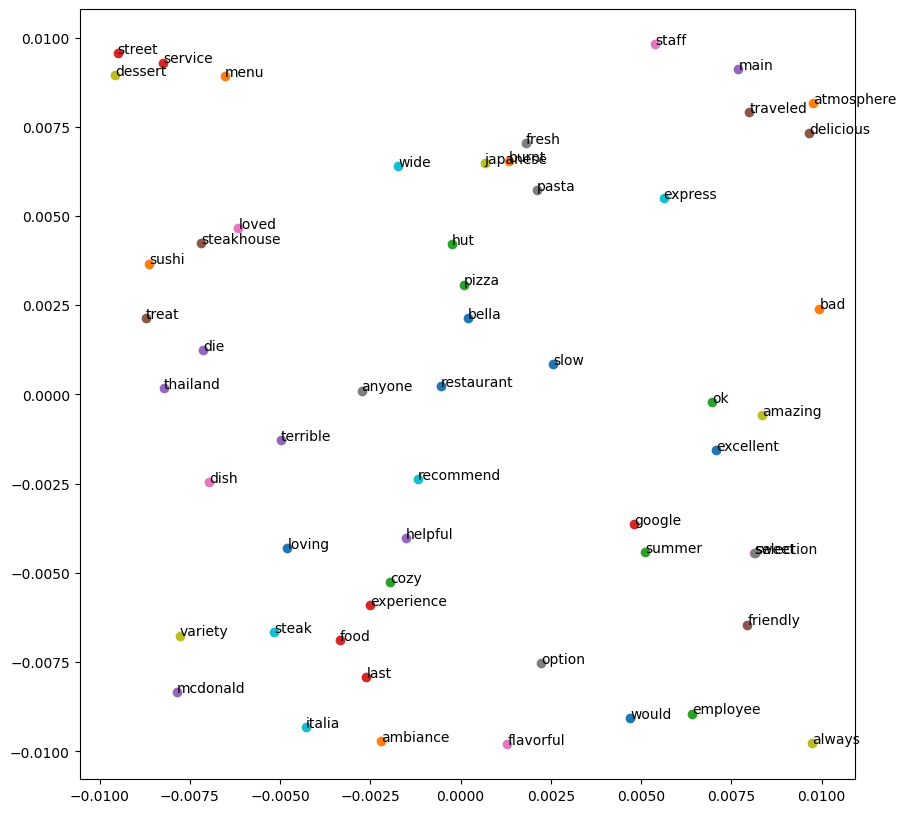

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# TODO: complete the plot_word_embeddings function
def plot_word_embeddings(model, words=None):
  plt.figure(figsize=(10, 10))
  if words is None:
    words = model.wv.index_to_key
  X = model.wv[words]
  for i, word in enumerate(words):
    plt.scatter(X[i, 0], X[i, 1])
    plt.annotate(word, xy=(X[i, 0], X[i, 1]))
  plt.show()

# TODO: call the plotting function using your trained model
plot_word_embeddings(w2v_model)

### 2.4 Go further
- Experiment with different preprocessing (e.g., bigrams, stemming vs lemmatization).
- Tune Word2Vec hyperparameters and compare the plots.
- Try dimensionality reduction (PCA/t-SNE) for richer visualizations.

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


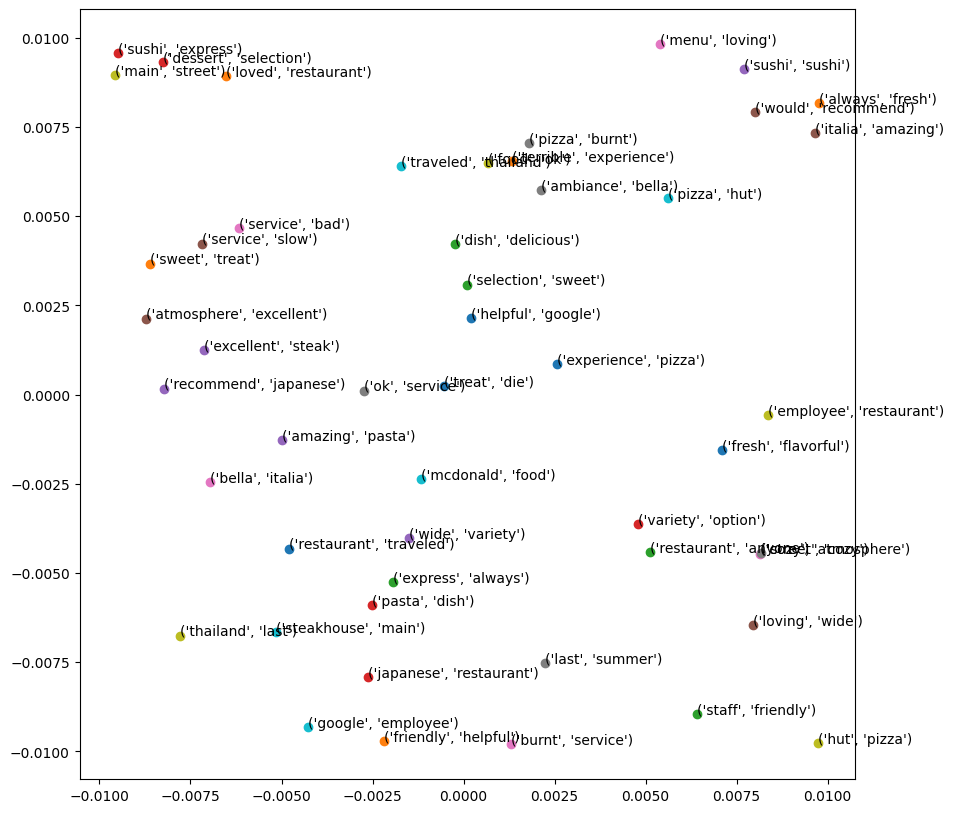

In [ ]:
from nltk import ngrams,bigrams
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from gensim.models import Word2Vec
nltk.download('wordnet')
#Experiment with different preprocessing (e.g., bigrams, stemming vs lemmatization).
#Use bigrams when single words lose meaning without context
bigrams_tokens = ([list(bigrams(review.split())) for review in cleaned_reviews])
#Tune Word2Vec hyperparameters and compare the plots.
model1 = Word2Vec(
    sentences=bigrams_tokens,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4)
plot_word_embeddings(model1)

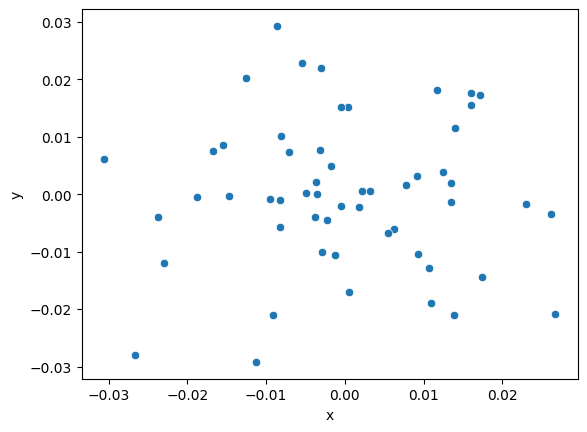

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
#Try dimensionality reduction (PCA/t-SNE) for richer visualizations.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(w2v_model.wv.vectors)
df = pd.DataFrame(X_pca, columns=['x', 'y'])
df['word'] = w2v_model.wv.index_to_key
sns.scatterplot(x='x', y='y', data=df)
plt.show()



